In [1]:
# Core libs (allowed by brief) + pandas (justified for CSV I/O & inspection)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [2]:
# Load dataset
df = pd.read_csv("Student Mental health.csv")

# Drop non-predictive timestamp if present
if "Timestamp" in df.columns:
    df = df.drop(columns=["Timestamp"])

print(df.shape)
df.head()


(101, 10)


,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


In [3]:
df.info()
print("\nMissing values per column:\n", df.isnull().sum())
df.describe(include="all").T


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 10 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Choose your gender                            101 non-null    object 
 1   Age                                           100 non-null    float64
 2   What is your course?                          101 non-null    object 
 3   Your current year of Study                    101 non-null    object 
 4   What is your CGPA?                            101 non-null    object 
 5   Marital status                                101 non-null    object 
 6   Do you have Depression?                       101 non-null    object 
 7   Do you have Anxiety?                          101 non-null    object 
 8   Do you have Panic attack?                     101 non-null    object 
 9   Did you seek any specialist for a treatment?  101 non-null    obj

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Choose your gender,101,2,Female,75,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,100.0,NaN,NaN,NaN,20.53,2.49628,18.0,18.0,19.0,23.0,24.0
What is your course?,101,48,BCS,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Your current year of Study,101,7,year 1,41,NaN,NaN,NaN,NaN,NaN,NaN,NaN
What is your CGPA?,101,5,3.50 - 4.00,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital status,101,2,No,85,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Do you have Depression?,101,2,No,66,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Do you have Anxiety?,101,2,No,67,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Do you have Panic attack?,101,2,No,68,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Did you seek any specialist for a treatment?,101,2,No,95,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
TARGET = "Do you have Depression?"

X = df.drop(columns=[TARGET])
y = df[TARGET].astype(str)

# Stratified split for class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

cat_cols = [c for c in X.columns if X[c].dtype == "object"]
num_cols = [c for c in X.columns if X[c].dtype != "object"]

cat_cols, num_cols


(['Choose your gender',
  'What is your course?',
  'Your current year of Study',
  'What is your CGPA?',
  'Marital status',
  'Do you have Anxiety?',
  'Do you have Panic attack?',
  'Did you seek any specialist for a treatment?'],
 ['Age'])

In [5]:
preprocess = ColumnTransformer(
    transformers=[
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median"))
        ]), num_cols)
    ]
)

dt = DecisionTreeClassifier(random_state=42, criterion="entropy")

pipe = Pipeline(steps=[("prep", preprocess), ("dt", dt)])
pipe


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Choose your gender',
                                                   'What is your course?',
                                                   'Your current year of Study',
                                                   'What is your CGPA?',
                                                   'Marital status',
                                                   'Do you have Anxiety?',
                                                   'Do you have Panic attack?',
                                                   'Did you seek any '
                                                   'specialist for a '
                                                   'treatment?']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Age'])])),
                ('dt',
                 DecisionTreeClassifier(criterion='entropy', random_state=42))])

In [6]:
param_grid = {
    "dt__max_depth": [3, 4, 5, 6, 8, None],
    "dt__min_samples_split": [2, 5, 10, 20],
    "dt__min_samples_leaf": [1, 2, 5, 10],
    "dt__ccp_alpha": [0.0, 0.001, 0.005, 0.01],  # cost-complexity pruning
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring="accuracy")
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Mean CV accuracy:", grid.best_score_)
best = grid.best_estimator_


Best params: {'dt__ccp_alpha': 0.0, 'dt__max_depth': 3, 'dt__min_samples_leaf': 1, 'dt__min_samples_split': 2}
Mean CV accuracy: 0.7866666666666667


In [7]:
y_pred = best.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

labels = best.classes_
cm = confusion_matrix(y_test, y_pred, labels=labels)
cm, labels


Test Accuracy: 0.8076923076923077

Classification Report:
               precision    recall  f1-score   support

          No       0.77      1.00      0.87        17
         Yes       1.00      0.44      0.62         9

    accuracy                           0.81        26
   macro avg       0.89      0.72      0.74        26
weighted avg       0.85      0.81      0.78        26



(array([[17,  0],
        [ 5,  4]]),
 array(['No', 'Yes'], dtype=object))

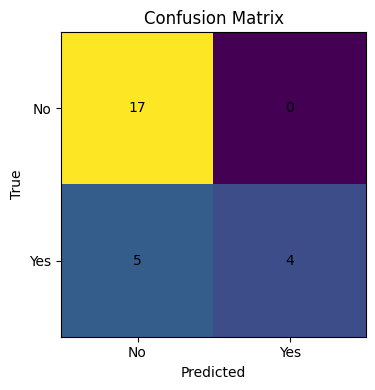

In [8]:
plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.xticks(range(len(labels)), labels)
plt.yticks(range(len(labels)), labels)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


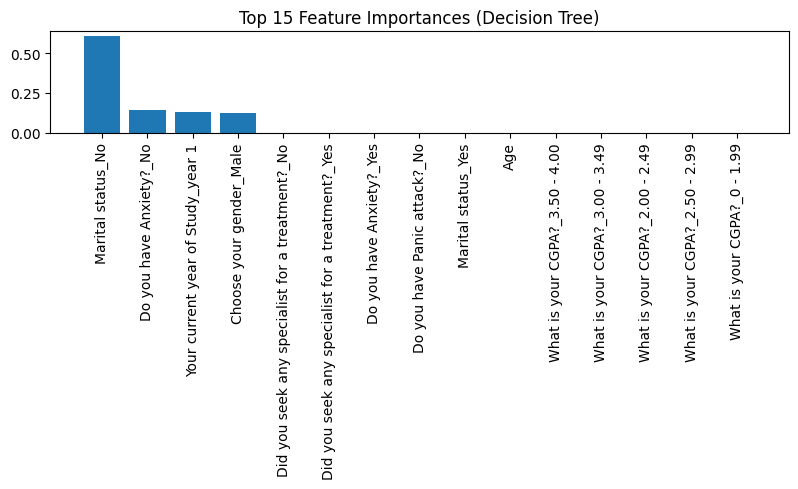

In [9]:
# Get post-encoding feature names
ohe = best.named_steps["prep"].named_transformers_["cat"].named_steps["onehot"]
ohe_names = ohe.get_feature_names_out(cat_cols)
feat_names = np.concatenate([ohe_names, np.array(num_cols)])

importances = best.named_steps["dt"].feature_importances_
order = np.argsort(importances)[::-1][:15]  # top 15 for readability

plt.figure(figsize=(8, 5))
plt.bar(range(len(order)), importances[order])
plt.xticks(range(len(order)), feat_names[order], rotation=90)
plt.title("Top 15 Feature Importances (Decision Tree)")
plt.tight_layout()
plt.show()


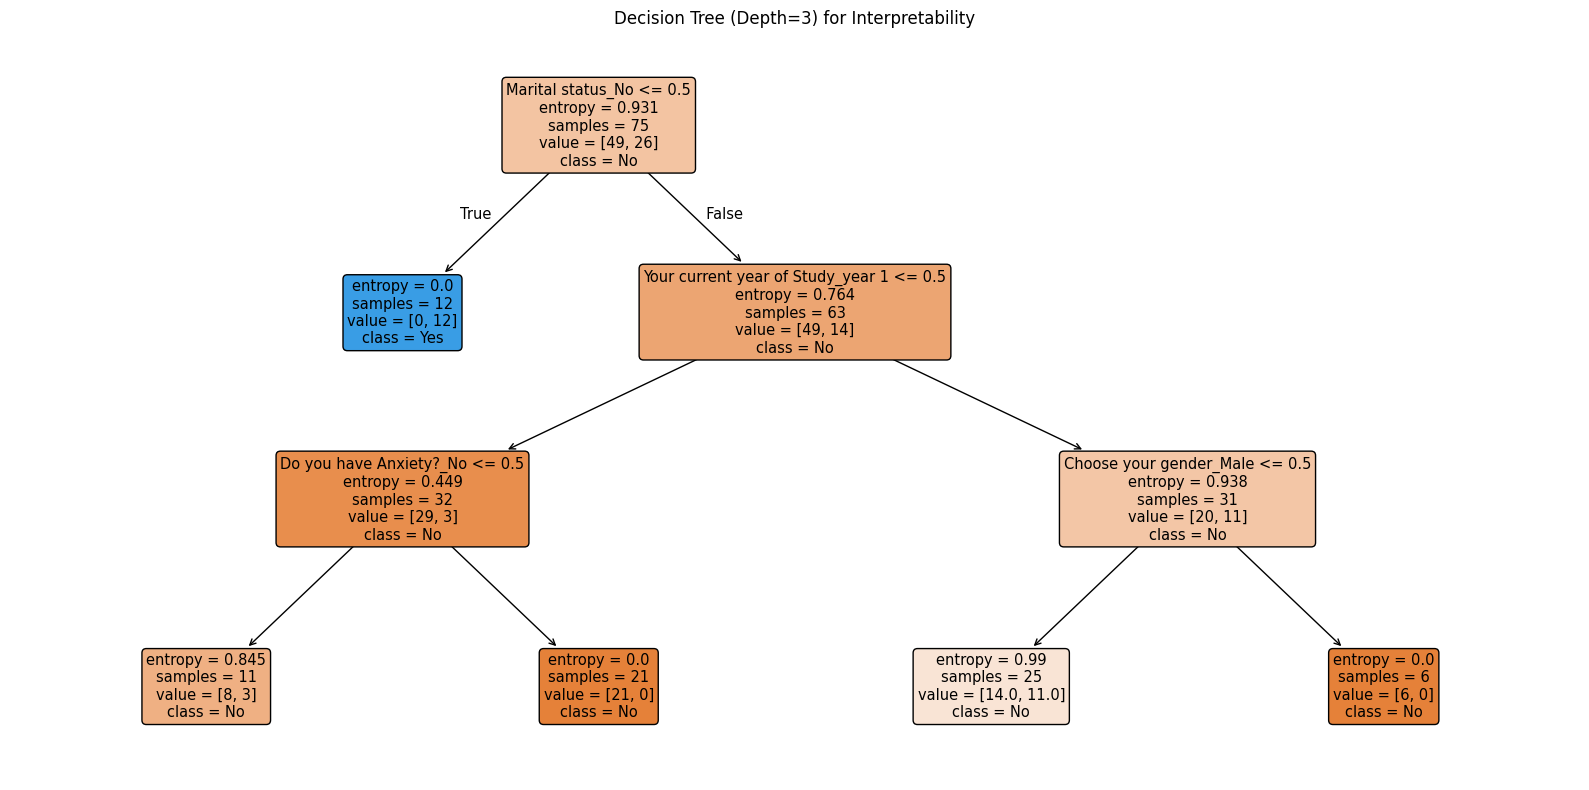

In [10]:
# Fit a shallow copy (depth=3) on the already-transformed training data for a readable plot
from sklearn.tree import DecisionTreeClassifier

Xt_train = best.named_steps["prep"].fit_transform(X_train)

shallow = DecisionTreeClassifier(
    random_state=42,
    criterion="entropy",
    max_depth=3,
    ccp_alpha=best.named_steps["dt"].ccp_alpha,
    min_samples_leaf=best.named_steps["dt"].min_samples_leaf,
    min_samples_split=best.named_steps["dt"].min_samples_split,
)
shallow.fit(Xt_train, y_train)

plt.figure(figsize=(16, 8))
plot_tree(
    shallow,
    feature_names=feat_names,
    class_names=list(labels),
    filled=True,
    rounded=True,
)
plt.title("Decision Tree (Depth=3) for Interpretability")
plt.tight_layout()
plt.show()
